# Synthetic Parameter Recovery via Laplace — condition-stratified, WITH Beta-mixture linking function

Companion to `model-synthetic-recovery-laplace-condition-stratified-no-linking.ipynb`. **Same Laplace
inference** (deterministic `log Z(theta)` via a mode + Hessian of the ratings-conditioned coherence
posterior), but the ratings likelihood now uses the **2-component Beta-mixture linking function**
instead of the single-global-kappa "prevalence = coherence" likelihood.

**Why both notebooks exist.** No-linking is the maximally-identifiable end: coherence IS the predicted
prevalence, so `(length_scale, mu_0)` have no nuisance flexibility to hide behind. Adding the linking
function reintroduces per-feature Beta-mixture shapes that can absorb some cross-feature prevalence
contrast — so comparing recovery here vs. no-linking isolates *how much the linking function's
flexibility degrades identifiability of the GP hyperparameters*. Running both under the SAME good
(Laplace) inference means any difference is about the linking function, not the estimator.

**Linking function.** Each rating is a draw from a 2-component Beta mixture where the coherence sets
the mixture WEIGHT:
`r_ij ~ pz1_j * Beta(a_kl, b_kl) + (1 - pz1_j) * Beta(a_nkl, b_nkl)`, with `pz1_j = sigmoid(y_test_j)`.
The `kl` ("kind-linked") component is high-mean, `nkl` ("not-kind-linked") is low-mean; the four
shape params are SHARED across conditions/features (the no-linking analogue was the single shared
`kappa`). Contrast the no-linking likelihood `Beta(kappa*pz1, kappa*(1-pz1))`, where coherence sets
the Beta *mean* directly.

**Decisions baked in (parallel to the no-linking notebook):**
- **Linking shapes FIXED at their true (data-generating) values** during recovery — same reason
  `kappa` was fixed: once the ratings term is inside the posterior we Laplace-approximate, the shapes
  can't be fit from the very draws they shape. Fixing them isolates `(length_scale, mu_0)` recovery.
- **Differentiable Beta-mixture in JAX.** The real-data linking notebook fits shapes with scipy
  L-BFGS on `betainc` (no JAX gradient w.r.t. shape params). Here the shapes are fixed, so we score
  ratings under a differentiable log-mixture of `jax.scipy.stats.beta.logpdf` components via
  `logaddexp(log pz1 + logpdf_kl, log(1-pz1) + logpdf_nkl)` — differentiable in `y`, as Laplace needs.
- **Recovery run one parameter at a time (ls-only, mu_0-only) THEN jointly (ls, mu_0).**
- **True `length_scale = 0.5`** (in the identifiable regime per the real-data distance-vs-prevalence
  diagnostic), so recovery isn't confounded by the `ls`-saturation plateau seen at ls=2.1.

**Laplace marginal likelihood (per condition).** Let
`g(y) = log_GP_prior(y|theta) + log_speaker(u_train | y_train) + sum_ij log[ pz1_j*Beta(r_ij|kl) + (1-pz1_j)*Beta(r_ij|nkl) ]`,
`pz1_j = sigmoid(y_test_j)`. Find the mode `y_hat`, `H = -grad^2 g(y_hat)`, `D = J + n_train`:

$$\log Z \approx g(\hat y) + \tfrac{D}{2}\log(2\pi) - \tfrac12 \log\det H.$$

Sum over conditions -> `log_lik`; add the `theta` prior -> `log_joint`. Deterministic, so VBMC runs
with `specify_target_noise=True` and a tiny nominal noise (avoids the gpyreg exact-path crash and
regularizes the surrogate GP).

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")   # float64 for stable log-det / Cholesky

import sys, pickle as pkl
sys.path.insert(0, ".")

import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax.scipy.stats import beta as jbeta
import matplotlib.pyplot as plt
from pyvbmc import VBMC

from model_jax import rbf_kernel, p_u_given_y, _mvn_logpdf_chol   # GP kernel + speaker + stable MVN

print(f"backend: {jax.default_backend()}  x64: {jax.config.jax_enable_x64}")

backend: cpu  x64: True


## Ground-truth parameters and feature geometry

Real feature embeddings and per-condition trained regions, so the spatial geometry matches the
experiment. **True `length_scale = 0.5`** sits below the feature-cloud diameter (~0.78), i.e. in the
regime where coherence genuinely decays across the cloud and `ls` is identifiable — unlike the
plateau-inducing ls=2.1. `TRUE_LINK_SHAPES` are the shared 2-component Beta-mixture linking shapes
used both to generate the ratings and (fixed) during recovery.

In [2]:
# Ground-truth parameters to recover
TRUE_PARAMS = {
    'length_scale': 0.4,   # in the identifiable regime (< cloud diameter ~0.78)
    'mu_0':         0.5,
    'output_scale': 1.5,
    'beta':         3.0,
}
# True Beta-mixture linking shapes, SHARED across conditions/features, FIXED during recovery.
# [a_kl, b_kl, a_nkl, b_nkl]: kl = high-mean "kind-linked" component (mean 0.8), nkl = low-mean
# "not-kind-linked" component (mean 0.2). Coherence pz1 = sigmoid(y_test) is the MIXTURE WEIGHT.
TRUE_LINK_SHAPES = np.array([8.0, 2.0, 2.0, 8.0])   # replaces KAPPA_TRUE from the no-linking notebook

with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)
train_df = df[df.split == 'train']
feat_idx = df.set_index('feature')

CONDITIONS  = ['diet', 'personality', 'physical', 'heterogeneous']
CAT_OF_COND = {'diet':'diet_preferences', 'personality':'personality_behaviors', 'physical':'physical'}
CAT_SHORT   = {'diet_preferences':'diet', 'personality_behaviors':'personality', 'physical':'physical'}

x_train_cond, u_train_cond = {}, {}
for c in CONDITIONS:
    sub = train_df[train_df.in_heterogenous] if c == 'heterogeneous' else train_df[train_df.category == CAT_OF_COND[c]]
    x_train_cond[c] = jnp.array(sub[['x_2d', 'y_2d']].values)
    u_train_cond[c] = jnp.zeros(len(sub), dtype=jnp.int32)   # all generic, localized to the region -- fixed by design
    print(f"  {c:<14}: {len(sub)} trained features")

CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':'can eat spicy food','diet_breakfast_late_1':'eat breakfast very late',
    'diet_five_meals_day_1':'eat five meals a day','diet_like_juice_pulp_1':'like juice with pulp',
    'diet_pepper_on_all_1':'put pepper on all their foods','pers_cry_easily_1':'cry easily',
    'pers_collect_rocks_1':'like to collect rocks','pers_like_to_dance_1':'like to dance',
    'pers_like_highfive_1':'like to give high-fives','pers_read_books_1':'like to read books',
    'phys_can_roll_tongue_1':'can roll their tongue','phys_can_snap_toes_1':'can snap with their toes',
    'phys_can_wiggle_ears_1':'can wiggle their ears','phys_cold_hands_feet_1':'have cold hands and feet',
    'phys_snore_sleep_1':'snore when they sleep'}
TEST_CSV_COLS      = list(CSV_TO_FEATURE.keys())
test_feature_names = list(CSV_TO_FEATURE.values())
x_test     = jnp.array([feat_idx.loc[n, ['x_2d','y_2d']].values for n in test_feature_names])  # (J,2)
test_trait = [CAT_SHORT[feat_idx.loc[n, 'category']] for n in test_feature_names]
J = x_test.shape[0]

a_kl, b_kl, a_nkl, b_nkl = TRUE_LINK_SHAPES
print(f"True params: ls={TRUE_PARAMS['length_scale']}, mu_0={TRUE_PARAMS['mu_0']}")
print(f"Linking shapes: kl=Beta({a_kl},{b_kl}) mean={a_kl/(a_kl+b_kl):.2f}, "
      f"nkl=Beta({a_nkl},{b_nkl}) mean={a_nkl/(a_nkl+b_nkl):.2f}")

  diet          : 15 trained features
  personality   : 15 trained features
  physical      : 15 trained features
  heterogeneous : 15 trained features
True params: ls=0.4, mu_0=0.5
Linking shapes: kl=Beta(8.0,2.0) mean=0.80, nkl=Beta(2.0,8.0) mean=0.20


## 1. Sample per-condition latent coherences (true generative draw)

One independent GP coherence field per condition over `[x_test, x_train_cond[c]]`, at the true
hyperparameters (ls=0.5). The coherence `pz1 = sigmoid(y_test)` is the per-feature MIXTURE WEIGHT
that the linking function uses in the next cell. Same seed (37) as the other recovery notebooks.

In [3]:
rng = np.random.default_rng(37)

# test first then train (matches the GP density convention) -- one independent
# GP draw PER CONDITION, since each condition has its own trained region / coherence field.
y_test_true_cond, pz1_test_true_cond = {}, {}
for c in CONDITIONS:
    n_train_c = x_train_cond[c].shape[0]
    X_all = jnp.vstack([x_test, x_train_cond[c]])
    mu    = jnp.full(J + n_train_c, TRUE_PARAMS['mu_0'])
    K     = rbf_kernel(X_all, TRUE_PARAMS['length_scale'], TRUE_PARAMS['output_scale'])

    y_all = rng.multivariate_normal(np.array(mu), np.array(K))
    y_test_true_cond[c]   = y_all[:J]
    pz1_test_true_cond[c] = 1 / (1 + np.exp(-y_test_true_cond[c]))

    print(f"  {c:<14}: y_test range [{y_test_true_cond[c].min():.2f}, {y_test_true_cond[c].max():.2f}]  "
          f"pz1 range [{pz1_test_true_cond[c].min():.2f}, {pz1_test_true_cond[c].max():.2f}]  "
          f"(realized mean y_test={y_test_true_cond[c].mean():.3f}; true mu_0="
          f"{TRUE_PARAMS['mu_0']} -- sampling scatter means recovered mu_0 may shift slightly)")

  diet          : y_test range [-1.72, 0.50]  pz1 range [0.15, 0.62]  (realized mean y_test=-0.637; true mu_0=0.5 -- sampling scatter means recovered mu_0 may shift slightly)
  personality   : y_test range [-0.15, 0.57]  pz1 range [0.46, 0.64]  (realized mean y_test=0.223; true mu_0=0.5 -- sampling scatter means recovered mu_0 may shift slightly)
  physical      : y_test range [-1.37, 1.99]  pz1 range [0.20, 0.88]  (realized mean y_test=0.091; true mu_0=0.5 -- sampling scatter means recovered mu_0 may shift slightly)
  heterogeneous : y_test range [-0.53, 0.20]  pz1 range [0.37, 0.55]  (realized mean y_test=-0.168; true mu_0=0.5 -- sampling scatter means recovered mu_0 may shift slightly)


## 2. Sample ratings per condition (Beta-mixture linking function)

Each rating is a draw from the 2-component mixture where the coherence `pz1 = sigmoid(y_test)` is the
MIXTURE WEIGHT: with prob `pz1` draw from the high-mean `kl` component `Beta(a_kl, b_kl)`, else from
the low-mean `nkl` component `Beta(a_nkl, b_nkl)`. Shapes are shared across conditions/features. This
is the key difference from the no-linking notebook, where `pz1` set the Beta *mean* directly via a
single `kappa`. Ratings are rounded to the slider grid and clipped into `(0, 1)` so the continuous
`Beta.logpdf` stays finite.

  diet          : 100 participants -> responses (100, 15)
  personality   : 100 participants -> responses (100, 15)
  physical      : 100 participants -> responses (100, 15)
  heterogeneous : 100 participants -> responses (100, 15)


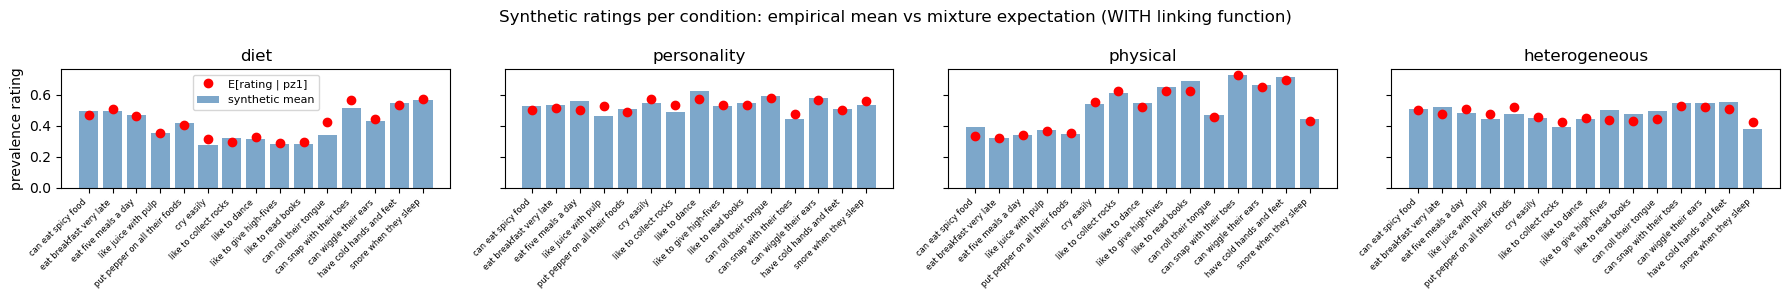

In [4]:
N_PARTICIPANTS_COND = {'diet': 100, 'personality': 100, 'physical': 100, 'heterogeneous': 100}
H = 1.0 / 200.0   # half a slider bin -- used to nudge exact 0/1 responses inward for Beta.logpdf

a_kl, b_kl, a_nkl, b_nkl = TRUE_LINK_SHAPES

responses_cond = {}
for c in CONDITIONS:
    Nc = N_PARTICIPANTS_COND[c]
    p  = np.clip(pz1_test_true_cond[c], 1e-4, 1 - 1e-4)          # (J,) mixture weight per feature
    # each participant: for each feature, pick the kl component w.p. pz1, else nkl, then draw a rating
    pick_kl = rng.random(size=(Nc, J)) < p[None, :]             # (N,J) bool
    draws_kl  = rng.beta(a_kl,  b_kl,  size=(Nc, J))
    draws_nkl = rng.beta(a_nkl, b_nkl, size=(Nc, J))
    draws = np.where(pick_kl, draws_kl, draws_nkl)
    r = np.round(draws * 100) / 100                              # discretize to slider grid
    r = np.clip(r, H, 1.0 - H)                                   # keep strictly interior for Beta.logpdf
    responses_cond[c] = jnp.array(r)
    print(f"  {c:<14}: {Nc} participants -> responses {responses_cond[c].shape}")

N_cond = {c: int(responses_cond[c].shape[0]) for c in CONDITIONS}

# expected rating per feature under the mixture = pz1*mean_kl + (1-pz1)*mean_nkl (for the overlay)
mean_kl, mean_nkl = a_kl/(a_kl+b_kl), a_nkl/(a_nkl+b_nkl)
fig, axes = plt.subplots(1, 4, figsize=(18, 3), sharey=True)
for ax, c in zip(axes, CONDITIONS):
    exp_rating = pz1_test_true_cond[c]*mean_kl + (1-pz1_test_true_cond[c])*mean_nkl
    ax.bar(range(J), np.array(responses_cond[c].mean(0)), color='steelblue', alpha=0.7, label='synthetic mean')
    ax.plot(range(J), exp_rating, 'ro', label='E[rating | pz1]')
    ax.set_xticks(range(J)); ax.set_xticklabels(test_feature_names, rotation=45, ha='right', fontsize=6)
    ax.set_title(c)
axes[0].set_ylabel('prevalence rating'); axes[0].legend(fontsize=8)
fig.suptitle('Synthetic ratings per condition: empirical mean vs mixture expectation (WITH linking function)')
plt.tight_layout(); plt.show()

## 3. Laplace marginal likelihood `log Z(theta)` per condition (Beta-mixture linking)

The differentiable log-posterior over the full coherence field `y = [y_test, y_train]`, at fixed
linking shapes:

```
g(y) = log_GP_prior(y | theta)                                    # MVN over [x_test, x_train]
     + sum_i log P_speaker(u_train_i | y_train_i, beta)           # RSA speaker on training utterances
     + sum_ij log[ pz1_j*Beta(r_ij|kl) + (1-pz1_j)*Beta(r_ij|nkl) ]   # mixture, pz1_j = sigmoid(y_test_j)
```

The ratings term is the log of a 2-component Beta mixture, computed via `logaddexp` so it stays
differentiable in `y` (the component `Beta.logpdf`s don't depend on `y` and are precomputed; only the
mixture WEIGHTS `pz1`/`1-pz1` do). We damped-Newton-minimize `-g` to the mode `y_hat`, take the
Hessian there, and return the Laplace `log Z`. Same machinery as the no-linking notebook — only the
ratings term differs.

In [5]:
from functools import partial

EPS = 1e-6   # keep sigmoid(y_test) and mixture weights off 0/1

def make_neg_log_post(x_train_c, u_train_c, responses_c, params, link_shapes):
    '''Returns jitted neg log-posterior over the flat coherence vector y = concat([y_test, y_train]).

    g(y) = GP prior + speaker(u_train|y_train) + Beta-MIXTURE ratings(r | pz1=sigmoid(y_test)).
    Ratings likelihood per (i,j):  pz1_j*Beta(r|a_kl,b_kl) + (1-pz1_j)*Beta(r|a_nkl,b_nkl),
    computed in log space via logaddexp -> differentiable in y (jax.scipy.stats.beta.logpdf).'''
    n_train = x_train_c.shape[0]
    X_all   = jnp.vstack([x_test, x_train_c])                 # (J + n_train, 2), test first
    mu_vec  = jnp.full(J + n_train, params['mu_0'])
    K       = rbf_kernel(X_all, params['length_scale'], params['output_scale'])
    beta    = params['beta']
    r       = jnp.asarray(responses_c)                        # (N, J)
    a_kl, b_kl, a_nkl, b_nkl = [float(v) for v in link_shapes]

    # per-feature Beta log-densities are the SAME for every participant (shapes are shared &
    # fixed), so precompute the (N,J) component logpdfs once -- they don't depend on y.
    logpdf_kl  = jbeta.logpdf(r, a_kl,  b_kl)                 # (N, J)
    logpdf_nkl = jbeta.logpdf(r, a_nkl, b_nkl)               # (N, J)

    @jax.jit
    def neg_log_post(y):
        y_test  = y[:J]
        y_train = y[J:]

        log_gp = _mvn_logpdf_chol(y, mu_vec, K)

        def log_utt_fn(u_i, y_i):
            return jnp.log(p_u_given_y(u_i, y_i, beta) + 1e-300)
        log_speaker = jnp.sum(jax.vmap(log_utt_fn)(u_train_c, y_train))

        pz1 = jnp.clip(jax.nn.sigmoid(y_test), EPS, 1.0 - EPS)   # (J,) mixture weight
        log_w_kl  = jnp.log(pz1)[None, :]                        # (1, J)
        log_w_nkl = jnp.log1p(-pz1)[None, :]
        # log[ pz1*Beta_kl + (1-pz1)*Beta_nkl ] per (i,j), differentiable in pz1 (hence y)
        log_mix = jnp.logaddexp(log_w_kl + logpdf_kl, log_w_nkl + logpdf_nkl)   # (N, J)
        log_ratings = jnp.sum(log_mix)

        return -(log_gp + log_speaker + log_ratings)

    return neg_log_post, (J + n_train)


def laplace_log_Z(x_train_c, u_train_c, responses_c, params, link_shapes,
                  n_newton=100, tol=1e-8):
    '''Laplace approx of log p(ratings_c | theta) for one condition, Beta-mixture linking function.

    DAMPED Newton (backtracking line search) minimizes -g(y) to the mode, then
    log Z = g(y_hat) + D/2 log(2pi) - 1/2 log det H, with H = grad^2 (-g)(y_hat) = posterior
    precision. Returns (log_Z, y_hat, ok).'''
    neg_log_post, D = make_neg_log_post(x_train_c, u_train_c, responses_c, params, link_shapes)
    val_fn  = jax.jit(neg_log_post)
    grad_fn = jax.jit(jax.grad(neg_log_post))
    hess_fn = jax.jit(jax.hessian(neg_log_post))

    y = jnp.full(D, params['mu_0'])          # init at the GP mean (mu_0)
    f = float(val_fn(y))
    for _ in range(n_newton):
        g  = grad_fn(y)
        Hm = hess_fn(y) + 1e-6 * jnp.eye(D)  # numerical PD guard
        step = jnp.linalg.solve(Hm, g)
        # backtracking (Armijo) line search along the Newton direction
        t, accepted = 1.0, False
        for _ls in range(30):
            y_try = y - t * step
            f_try = float(val_fn(y_try))
            if np.isfinite(f_try) and f_try <= f - 1e-4 * t * float(jnp.dot(g, step)):
                accepted = True; break
            t *= 0.5
        if not accepted:
            break                            # can't decrease further -> at (or stuck near) the mode
        converged = float(jnp.max(jnp.abs(y_try - y))) < tol
        y, f = y_try, f_try
        if converged:
            break

    Hm = hess_fn(y) + 1e-6 * jnp.eye(D)
    sign, logdet = jnp.linalg.slogdet(Hm)
    gnorm = float(jnp.max(jnp.abs(grad_fn(y))))     # gradient at the mode should be ~0
    log_Z = -f + 0.5 * D * jnp.log(2.0 * jnp.pi) - 0.5 * logdet
    ok = bool(sign > 0) and bool(np.isfinite(log_Z)) and gnorm < 1e-2
    return float(log_Z), np.asarray(y), ok

print("defined make_neg_log_post, laplace_log_Z (Beta-mixture linking function)")

defined make_neg_log_post, laplace_log_Z (Beta-mixture linking function)


### Sanity check: `log Z` and the recovered coherence mode at the TRUE params

Before any optimization, evaluate the Laplace estimator at the true `(ls, mu_0, kappa)` and confirm
(a) the mode-find converges and the Hessian is PD in every condition, and (b) the posterior-mode
`pz1 = sigmoid(y_test_hat)` tracks each condition's TRUE pz1. If the mode doesn't recover the truth
here, nothing downstream can.

  diet          : log_Z=     370.8  Hessian PD & converged=True  r(mode pz1, true pz1)=+0.972
  personality   : log_Z=     219.0  Hessian PD & converged=True  r(mode pz1, true pz1)=+0.802
  physical      : log_Z=     363.4  Hessian PD & converged=True  r(mode pz1, true pz1)=+0.996
  heterogeneous : log_Z=     207.3  Hessian PD & converged=True  r(mode pz1, true pz1)=+0.916


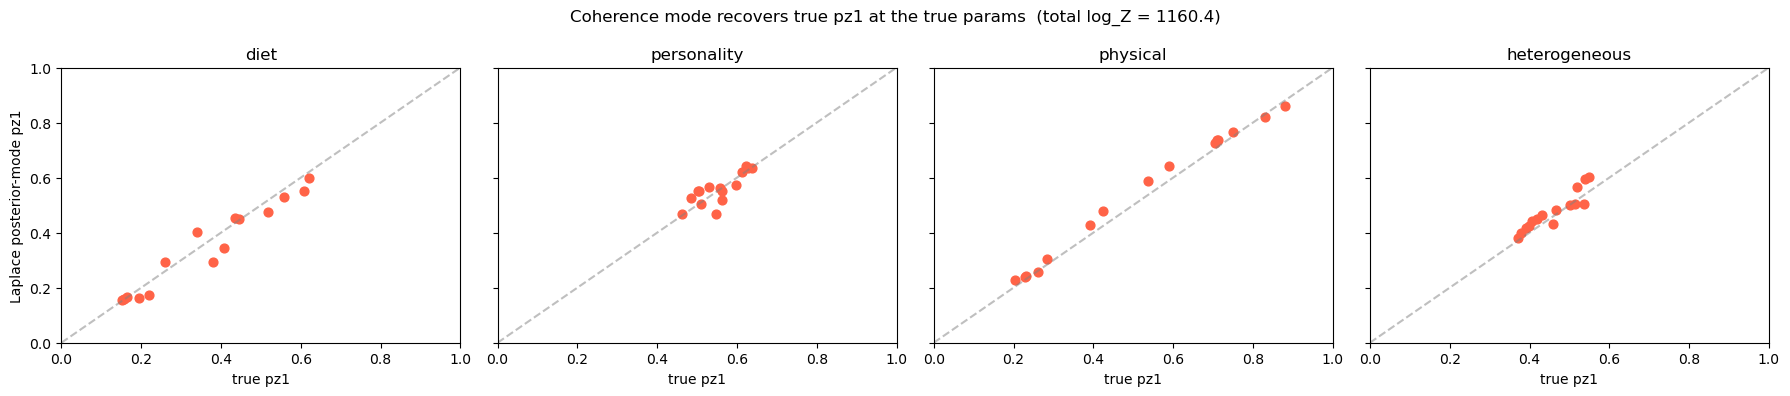

In [6]:
FIXED_PARAMS = {'output_scale': TRUE_PARAMS['output_scale'], 'beta': TRUE_PARAMS['beta']}
params_true  = {**FIXED_PARAMS, 'length_scale': TRUE_PARAMS['length_scale'], 'mu_0': TRUE_PARAMS['mu_0']}

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
total_logZ = 0.0
for ax, c in zip(axes, CONDITIONS):
    logZ, y_hat, ok = laplace_log_Z(x_train_cond[c], u_train_cond[c], responses_cond[c],
                                    params_true, TRUE_LINK_SHAPES)
    total_logZ += logZ
    pz1_mode = 1.0 / (1.0 + np.exp(-y_hat[:J]))
    r_mode_true = np.corrcoef(pz1_test_true_cond[c], pz1_mode)[0, 1]
    print(f"  {c:<14}: log_Z={logZ:10.1f}  Hessian PD & converged={ok}  r(mode pz1, true pz1)={r_mode_true:+.3f}")
    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
    ax.scatter(pz1_test_true_cond[c], pz1_mode, s=40, color='tomato')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('true pz1'); ax.set_title(c)
axes[0].set_ylabel('Laplace posterior-mode pz1')
fig.suptitle(f'Coherence mode recovers true pz1 at the true params  (total log_Z = {total_logZ:.1f})')
plt.tight_layout(); plt.show()

### Deterministic-objective check: is `log Z(theta)` smooth and peaked near the truth?

The whole reason for Laplace is a noise-free objective. Slice the summed `log Z` along each
parameter (holding the other + kappa at truth) and confirm it's smooth and peaks at/near the true
value — the opposite of the noisy, boundary-seeking IS objective. This is the single most
diagnostic plot in the notebook: if these slices peak at the truth, VBMC will too.

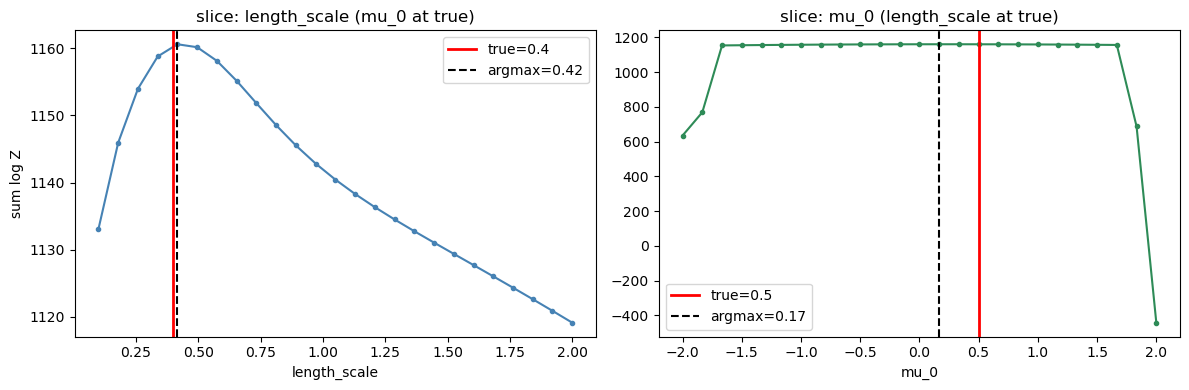

In [7]:
def total_log_lik(length_scale, mu_0, link_shapes=TRUE_LINK_SHAPES):
    '''Sum of Laplace log Z across conditions at the given params (no theta-prior).'''
    params = {**FIXED_PARAMS, 'length_scale': float(length_scale), 'mu_0': float(mu_0)}
    return sum(laplace_log_Z(x_train_cond[c], u_train_cond[c], responses_cond[c], params, link_shapes)[0]
               for c in CONDITIONS)

ls_grid = np.linspace(0.1, 2.0, 25)   # centered on the ls=0.4 identifiable regime
mu_grid = np.linspace(-2.0, 2.0, 25)
ll_ls = np.array([total_log_lik(ls, TRUE_PARAMS['mu_0']) for ls in ls_grid])
ll_mu = np.array([total_log_lik(TRUE_PARAMS['length_scale'], mu) for mu in mu_grid])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ls_grid, ll_ls, '-o', ms=3, color='steelblue')
axes[0].axvline(TRUE_PARAMS['length_scale'], color='red', lw=2, label=f"true={TRUE_PARAMS['length_scale']}")
axes[0].axvline(ls_grid[np.argmax(ll_ls)], color='k', ls='--', label=f'argmax={ls_grid[np.argmax(ll_ls)]:.2f}')
axes[0].set_xlabel('length_scale'); axes[0].set_ylabel('sum log Z'); axes[0].set_title('slice: length_scale (mu_0 at true)'); axes[0].legend()
axes[1].plot(mu_grid, ll_mu, '-o', ms=3, color='seagreen')
axes[1].axvline(TRUE_PARAMS['mu_0'], color='red', lw=2, label=f"true={TRUE_PARAMS['mu_0']}")
axes[1].axvline(mu_grid[np.argmax(ll_mu)], color='k', ls='--', label=f'argmax={mu_grid[np.argmax(ll_mu)]:.2f}')
axes[1].set_xlabel('mu_0'); axes[1].set_title('slice: mu_0 (length_scale at true)'); axes[1].legend()
plt.tight_layout(); plt.show()

## 4. VBMC objective (deterministic, with a nominal target noise)

`log_joint(phi) = sum_c laplace_log_Z_c + log_prior(theta)`. Same priors as the NUTS notebook:
`log_ls ~ N(log 0.5, 1.5^2)`, `mu_0 ~ N(0, 1)`.

The objective is **deterministic** (no Monte Carlo), but we still run VBMC with
`specify_target_noise=True` and return a tiny constant `TARGET_NOISE`. Running in the exact-observation
mode triggers a gradient bug in pyVBMC/gpyreg's GP-hyperparameter fit (`ValueError: setting an array
element with a sequence` inside `train_gp`); the noisy path avoids it and also regularizes the
surrogate GP over the very flat length_scale plateau. `TARGET_NOISE` is negligible vs the objective's
~80-unit spread, so the recovered posterior is unaffected.

In [8]:
MAX_EVALS    = 100
MAX_EVALS_1D = 60

# The Laplace objective is DETERMINISTIC, but we still declare a tiny observation noise to VBMC and
# run it with specify_target_noise=True. Two reasons:
#  (1) pyVBMC/gpyreg's EXACT-observation GP path has a noise-hyperparameter gradient bug that crashes
#      train_gp with "ValueError: setting an array element with a sequence" on this problem. The noisy
#      path avoids that code entirely.
#  (2) a small jitter regularizes the surrogate GP over the objective.
# TARGET_NOISE is tiny relative to the spread of log_joint, so it does not smear the posterior.
TARGET_NOISE = 1.0

def log_prior_ls(log_ls):  return float(-0.5 * ((log_ls - np.log(0.5)) / 1.5) ** 2)
def log_prior_mu(mu_0):    return float(-0.5 * mu_0 ** 2)

_eval = [0]
def log_joint(phi):
    '''Full 2D objective. phi = [log_ls, mu_0]; linking shapes fixed at TRUE_LINK_SHAPES.
    Returns (value, noise_std) because VBMC is run with specify_target_noise=True.'''
    phi = np.asarray(phi).ravel()
    log_ls, mu_0 = float(phi[0]), float(phi[1])
    ls = float(np.exp(log_ls))
    _eval[0] += 1
    ll = total_log_lik(ls, mu_0)
    lp = log_prior_ls(log_ls) + log_prior_mu(mu_0)
    val = ll + lp
    print(f"  eval {_eval[0]:3d}: ls={ls:.3f}  mu_0={mu_0:+.3f}  log_lik={ll:.1f}  log_joint={val:.1f}")
    return val, TARGET_NOISE

print(f"defined log_joint; linking shapes fixed at {TRUE_LINK_SHAPES}; target_noise={TARGET_NOISE}")

defined log_joint; linking shapes fixed at [8. 2. 2. 8.]; target_noise=1.0


## 5. Recovery: one parameter at a time

First isolate each parameter (the other + kappa fixed at truth). If a parameter recovers well alone
but not jointly, the issue is the ridge/confound between them; if it fails even alone, it's
individually unidentifiable from this data. With the noise gone, either outcome is now a clean
*modeling* statement rather than an inference artifact.

### 5a. length_scale only (mu_0, kappa fixed at true)

In [9]:
_n_ls = [0]
def log_joint_ls_only(phi):
    log_ls = float(np.asarray(phi).ravel()[0]); ls = float(np.exp(log_ls))
    _n_ls[0] += 1
    ll = total_log_lik(ls, TRUE_PARAMS['mu_0'])
    val = ll + log_prior_ls(log_ls)
    print(f"  [ls-only] {_n_ls[0]:3d}: ls={ls:.3f}  log_lik={ll:.1f}")
    return val, TARGET_NOISE

vbmc_ls = VBMC(log_joint_ls_only,
               np.array([np.log(1.5)]), np.array([np.log(0.03)]), np.array([np.log(2.5)]),
               np.array([np.log(0.08)]), np.array([np.log(1.0)]),
               options={'specify_target_noise': True, 'max_fun_evals': MAX_EVALS_1D})
res_ls, stats_ls = vbmc_ls.optimize()
ls_post = np.exp(res_ls.sample(int(1e4))[0][:, 0])
print(f"\nlengthscale-only:  true={TRUE_PARAMS['length_scale']}   median={np.median(ls_post):.3f}   "
      f"95% CI [{np.percentile(ls_post,2.5):.3f}, {np.percentile(ls_post,97.5):.3f}]   ({stats_ls['convergence_status']})")

Reshaping x0 to row vector.
Reshaping lower bounds to (1, 1).
Reshaping upper bounds to (1, 1).
Reshaping plausible lower bounds to (1, 1).
Reshaping plausible upper bounds to (1, 1).
vbmc:InitialPointsOutsidePB. The starting points X0 are not inside the provided plausible bounds PLB and PUB. Expanding the plausible bounds...
Beginning variational optimization assuming NOISY observations of the log-joint
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
  [ls-only]   1: ls=1.500  log_lik=1129.9
  [ls-only]   2: ls=0.092  log_lik=1131.3
  [ls-only]   3: ls=1.085  log_lik=1139.5
  [ls-only]   4: ls=0.774  log_lik=1150.1
  [ls-only]   5: ls=0.547  log_lik=1159.0
  [ls-only]   6: ls=0.481  log_lik=1160.4
  [ls-only]   7: ls=0.161  log_lik=1143.7
  [ls-only]   8: ls=0.130  log_lik=1139.0
  [ls-only]   9: ls=0.356  log_lik=1159.5
  [ls-only]  10: ls=0.370  log_lik=1159.9
     0         10        1159.29         0.51     71200.40        2        inf    

### 5b. mu_0 only (length_scale, kappa fixed at true)

In [10]:
_n_mu = [0]
def log_joint_mu_only(phi):
    mu_0 = float(np.asarray(phi).ravel()[0])
    _n_mu[0] += 1
    ll = total_log_lik(TRUE_PARAMS['length_scale'], mu_0)
    val = ll + log_prior_mu(mu_0)
    print(f"  [mu-only] {_n_mu[0]:3d}: mu_0={mu_0:+.3f}  log_lik={ll:.1f}")
    return val, TARGET_NOISE

vbmc_mu = VBMC(log_joint_mu_only,
               np.array([1.0]), np.array([-4.0]), np.array([4.0]),
               np.array([-2.0]), np.array([2.0]),
               options={'specify_target_noise': True, 'max_fun_evals': MAX_EVALS_1D})
res_mu, stats_mu = vbmc_mu.optimize()
mu0_post = res_mu.sample(int(1e4))[0][:, 0]
print(f"\nmu_0-only:  true={TRUE_PARAMS['mu_0']}   median={np.median(mu0_post):.3f}   "
      f"95% CI [{np.percentile(mu0_post,2.5):.3f}, {np.percentile(mu0_post,97.5):.3f}]   ({stats_mu['convergence_status']})")

Reshaping x0 to row vector.
Reshaping lower bounds to (1, 1).
Reshaping upper bounds to (1, 1).
Reshaping plausible lower bounds to (1, 1).
Reshaping plausible upper bounds to (1, 1).
Beginning variational optimization assuming NOISY observations of the log-joint
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
  [mu-only]   1: mu_0=+1.000  log_lik=1159.4
  [mu-only]   2: mu_0=+1.365  log_lik=1158.1
  [mu-only]   3: mu_0=-0.650  log_lik=1159.2
  [mu-only]   4: mu_0=-1.732  log_lik=1153.4
  [mu-only]   5: mu_0=+1.374  log_lik=1158.0
  [mu-only]   6: mu_0=+0.951  log_lik=1159.6
  [mu-only]   7: mu_0=+0.374  log_lik=1160.5
  [mu-only]   8: mu_0=+1.612  log_lik=1156.9
  [mu-only]   9: mu_0=-0.451  log_lik=1159.7
  [mu-only]  10: mu_0=+0.278  log_lik=1160.6
     0         10        1160.87         0.15    805144.32        2        inf     start warm-up
  [mu-only]  11: mu_0=+0.025  log_lik=1160.5
  [mu-only]  12: mu_0=+0.623  log_lik=1160.3
  [mu-onl

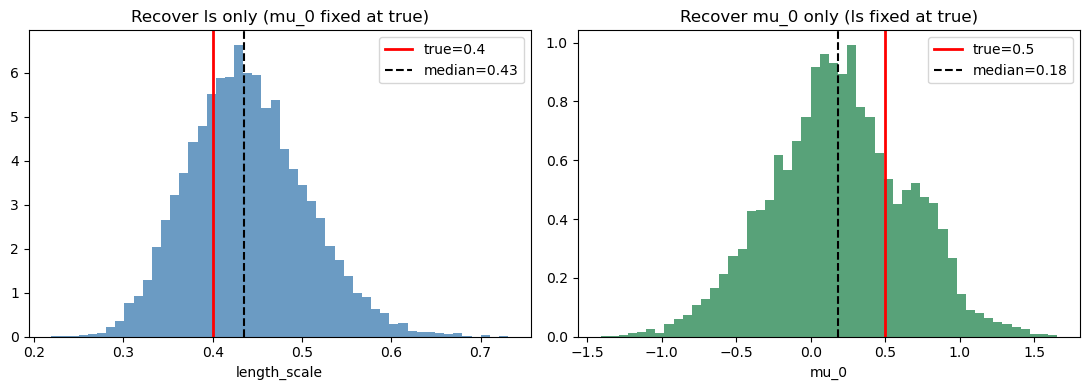

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(ls_post, bins=50, density=True, color='steelblue', alpha=0.8)
axes[0].axvline(TRUE_PARAMS['length_scale'], color='red', lw=2, label=f"true={TRUE_PARAMS['length_scale']}")
axes[0].axvline(np.median(ls_post), color='k', ls='--', label=f'median={np.median(ls_post):.2f}')
axes[0].set_xlabel('length_scale'); axes[0].set_title('Recover ls only (mu_0 fixed at true)'); axes[0].legend()
axes[1].hist(mu0_post, bins=50, density=True, color='seagreen', alpha=0.8)
axes[1].axvline(TRUE_PARAMS['mu_0'], color='red', lw=2, label=f"true={TRUE_PARAMS['mu_0']}")
axes[1].axvline(np.median(mu0_post), color='k', ls='--', label=f'median={np.median(mu0_post):.2f}')
axes[1].set_xlabel('mu_0'); axes[1].set_title('Recover mu_0 only (ls fixed at true)'); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Joint recovery: (length_scale, mu_0)

Both parameters together, kappa fixed. Start away from the truth so it's a real test.

In [12]:
_eval[0] = 0
x0  = np.array([np.log(0.3), 0.0])
lb  = np.array([np.log(0.03), -4.0])
ub  = np.array([np.log(2.5),   4.0])
plb = np.array([np.log(0.08), -2.0])
pub = np.array([np.log(1.0),   2.0])
print(f"Start: ls={np.exp(x0[0]):.2f}, mu_0={x0[1]:.2f}  (true: ls={TRUE_PARAMS['length_scale']}, mu_0={TRUE_PARAMS['mu_0']})")

vbmc = VBMC(log_joint, x0, lb, ub, plb, pub,
            options={'specify_target_noise': True, 'max_fun_evals': MAX_EVALS})
vbmc_result, vbmc_stats = vbmc.optimize()

Start: ls=0.30, mu_0=0.00  (true: ls=0.4, mu_0=0.5)
Reshaping x0 to row vector.
Reshaping lower bounds to (1, 2).
Reshaping upper bounds to (1, 2).
Reshaping plausible lower bounds to (1, 2).
Reshaping plausible upper bounds to (1, 2).
Beginning variational optimization assuming NOISY observations of the log-joint
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
  eval   1: ls=0.300  mu_0=+0.000  log_lik=1157.5  log_joint=1157.4
  eval   2: ls=0.347  mu_0=+0.659  log_lik=1158.8  log_joint=1158.6
  eval   3: ls=0.184  mu_0=+0.172  log_lik=1147.5  log_joint=1147.3
  eval   4: ls=0.336  mu_0=-0.077  log_lik=1159.1  log_joint=1159.0
  eval   5: ls=0.713  mu_0=-0.266  log_lik=1151.5  log_joint=1151.4
  eval   6: ls=0.364  mu_0=+1.951  log_lik=762.4  log_joint=760.5
  eval   7: ls=0.096  mu_0=-1.573  log_lik=1119.6  log_joint=1117.8
  eval   8: ls=0.780  mu_0=+1.464  log_lik=1149.2  log_joint=1148.0
  eval   9: ls=0.609  mu_0=-0.154  log_lik=1156.1  l

param             true   post mean  post median                95% CI
length_scale     0.400       0.427        0.422   [0.313, 0.562]
mu_0             0.500       0.168        0.157   [-0.731, 1.011]

convergence: no  (evals: 100, ELBO: 1159.6)


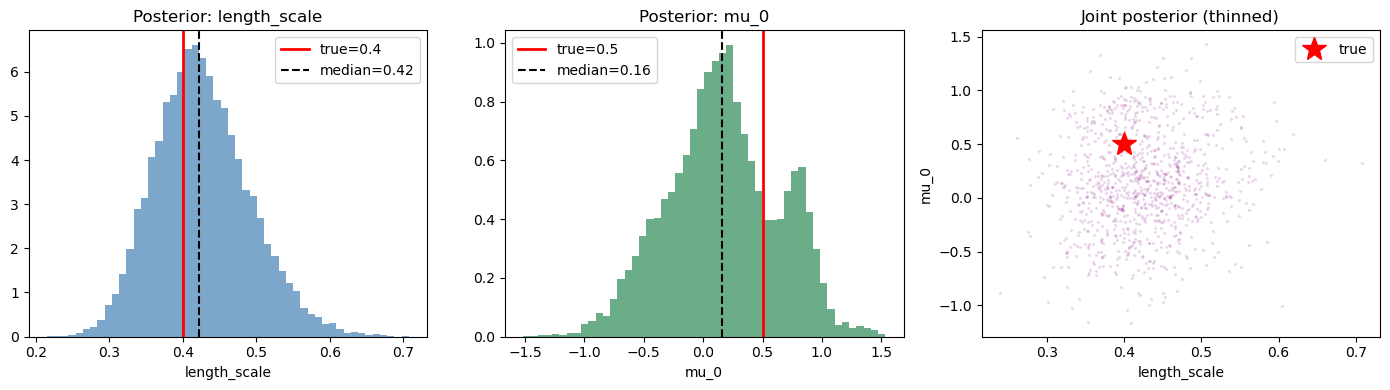

In [13]:
phi_samples, _ = vbmc_result.sample(int(1e4))
ls_samples  = np.exp(phi_samples[:, 0])
mu0_samples = phi_samples[:, 1]
ls_true, mu0_true = TRUE_PARAMS['length_scale'], TRUE_PARAMS['mu_0']

print(f"{'param':<14}{'true':>8}{'post mean':>12}{'post median':>13}{'95% CI':>22}")
print(f"{'length_scale':<14}{ls_true:>8.3f}{ls_samples.mean():>12.3f}{np.median(ls_samples):>13.3f}"
      f"   [{np.percentile(ls_samples,2.5):.3f}, {np.percentile(ls_samples,97.5):.3f}]")
print(f"{'mu_0':<14}{mu0_true:>8.3f}{mu0_samples.mean():>12.3f}{np.median(mu0_samples):>13.3f}"
      f"   [{np.percentile(mu0_samples,2.5):.3f}, {np.percentile(mu0_samples,97.5):.3f}]")
print(f"\nconvergence: {vbmc_stats['convergence_status']}  (evals: {vbmc_stats['func_count']}, ELBO: {vbmc_stats['elbo']:.1f})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(ls_samples, bins=50, density=True, color='steelblue', alpha=0.7)
axes[0].axvline(ls_true, color='red', lw=2, label=f'true={ls_true}')
axes[0].axvline(np.median(ls_samples), color='k', ls='--', lw=1.5, label=f'median={np.median(ls_samples):.2f}')
axes[0].set_xlabel('length_scale'); axes[0].set_title('Posterior: length_scale'); axes[0].legend()
axes[1].hist(mu0_samples, bins=50, density=True, color='seagreen', alpha=0.7)
axes[1].axvline(mu0_true, color='red', lw=2, label=f'true={mu0_true}')
axes[1].axvline(np.median(mu0_samples), color='k', ls='--', lw=1.5, label=f'median={np.median(mu0_samples):.2f}')
axes[1].set_xlabel('mu_0'); axes[1].set_title('Posterior: mu_0'); axes[1].legend()
axes[2].scatter(ls_samples[::10], mu0_samples[::10], alpha=0.1, s=2, color='purple')
axes[2].plot(ls_true, mu0_true, 'r*', ms=18, label='true')
axes[2].set_xlabel('length_scale'); axes[2].set_ylabel('mu_0')
axes[2].set_title('Joint posterior (thinned)'); axes[2].legend()
plt.tight_layout(); plt.show()